# Bot, Collaborative, Human Notes Analysis

In [6]:
from google.colab import drive

drive.mount('/content/drive/')

BASE_DIR = "/content/drive/MyDrive"
FOLDERNAME = "INFO494"
DATA_DIR = f"{BASE_DIR}/{FOLDERNAME}"

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [3]:
!ls {DATA_DIR}

batSignals-00000.tsv	 noteStatusHistory-00000.tsv  ratings-00005.tsv
cn_bot_accounts_ids.csv  ratings-00000.tsv	      ratings-00006.tsv
filtered		 ratings-00001.tsv	      ratings-00007.tsv
notes-00000.tsv		 ratings-00002.tsv	      ratings_ai.csv
notes-00001.tsv		 ratings-00003.tsv	      userEnrollment-00000.tsv
notes_all.csv		 ratings-00004.tsv


## Create Bot, Collaborative, Human Notes data

In [4]:
import pandas as pd


In [ ]:
# Raw note files: notes-00000.tsv and notes-00001.tsv
notes_raw_0 = pd.read_csv(f"{DATA_DIR}/notes-00000.tsv", sep="\t", low_memory=False)
notes_raw_1 = pd.read_csv(f"{DATA_DIR}/notes-00001.tsv", sep="\t", low_memory=False)

KeyboardInterrupt: 

In [ ]:
notes_raw_1.columns

Index(['noteId', 'noteAuthorParticipantId', 'createdAtMillis', 'tweetId',
       'classification', 'believable', 'harmful', 'validationDifficulty',
       'misleadingOther', 'misleadingFactualError',
       'misleadingManipulatedMedia', 'misleadingOutdatedInformation',
       'misleadingMissingImportantContext', 'misleadingUnverifiedClaimAsFact',
       'misleadingSatire', 'notMisleadingOther',
       'notMisleadingFactuallyCorrect',
       'notMisleadingOutdatedButNotWhenWritten', 'notMisleadingClearlySatire',
       'notMisleadingPersonalOpinion', 'trustworthySources', 'summary',
       'isMediaNote', 'isCollaborativeNote'],
      dtype='object')

In [ ]:
# Bot account IDs provided by the research team
bot_accounts = pd.read_csv(f"{DATA_DIR}/cn_bot_accounts_ids.csv")

In [ ]:
bot_accounts.head()

,participantId,enrollmentState,successfulRatingNeededToEarnIn,timestampOfLastStateChange,timestampOfLastEarnOut,modelingPopulation,modelingGroup,numberOfTimesEarnedOut,_processing_commit_hash,_processed_at,_data_date
0,191F8B3CF22C564E5E0E7D70D50E94C2074763B001F371...,apiEarnedIn,0,1766011191170,1,CORE,13.0,0,16fdbe50a350d62f6a8f17fbc52e859eee1408d7,2026-02-24T00:11:14.299012,2026-02-24
1,191F8B3CF22C564E5E0E7D70D50E94C2074763B001F371...,apiEarnedIn,0,1766011191170,1,CORE,13.0,0,NaN,NaN,NaN
2,2E17D975042F20F745DAE5FCC7785CD2731C33F93D3DE6...,apiEarnedIn,0,1753742846239,1,CORE,13.0,0,NaN,NaN,NaN
3,2E17D975042F20F745DAE5FCC7785CD2731C33F93D3DE6...,apiEarnedIn,0,1753742846239,1,CORE,13.0,0,8f45484764bd28a12dfe0934251d7d59f0011c95,2025-11-26T00:09:19.367968,2025-11-26
4,2E17D975042F20F745DAE5FCC7785CD2731C33F93D3DE6...,apiEarnedIn,0,1753742846239,1,CORE,13.0,0,16703210a4814a8cb4641f44cbfb2e7c19a5a536,2025-12-26T00:09:01.024076,2025-12-26


In [ ]:
# Combine both note files into one note-level DataFrame
# Result: one row per note
notes = pd.concat([notes_raw_0, notes_raw_1], ignore_index=True)

In [ ]:
# Keep only tweets that have at least one collaborative note (isCollaborativeNote=1)
# Also collect all other notes (human/bot) written on those same tweets
n_tweets_before = notes["tweetId"].nunique()

tweet_collab_flag = notes.groupby("tweetId")["isCollaborativeNote"].max()
valid_tweet_ids = tweet_collab_flag[tweet_collab_flag == 1].index
notes = notes[notes["tweetId"].isin(valid_tweet_ids)].reset_index(drop=True)

n_tweets_after = notes["tweetId"].nunique()
print(f"Unique tweets before filter: {n_tweets_before}")
print(f"Unique tweets after filter:  {n_tweets_after}")
print(f"Dropped: {n_tweets_before - n_tweets_after}")

Unique tweets before filter: 1621277
Unique tweets after filter:  3340
Dropped: 1617937


In [ ]:
# Label each note as bot-written (isBot=1) or not (isBot=0)
# by matching noteAuthorParticipantId against the known bot account list
bot_participant_ids = set(bot_accounts["participantId"])
notes["isBot"] = notes["noteAuthorParticipantId"].isin(bot_participant_ids).astype(int)

In [ ]:
notes.to_csv(f"{DATA_DIR}/notes_all.csv", index=False)

### Plot Basic Stats

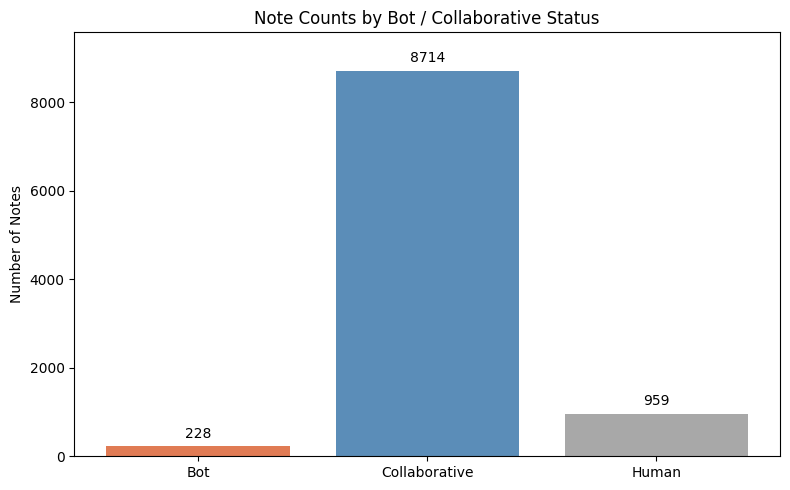

Bot: 228
Collaborative: 8714
Human: 959


In [ ]:
import matplotlib.pyplot as plt

# Count notes per category: Bot (bot-written, not collaborative),
# Collaborative (AI-assisted, not bot), Human (neither)
note_type_counts = {
    "Bot": ((notes["isBot"] == 1) & (notes["isCollaborativeNote"] == 0)).sum(),
    "Collaborative": ((notes["isBot"] == 0) & (notes["isCollaborativeNote"] == 1)).sum(),
    "Human": ((notes["isBot"] == 0) & (notes["isCollaborativeNote"] == 0)).sum(),
}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(note_type_counts.keys(), note_type_counts.values(),
              color=["#e07b54", "#5b8db8", "#a8a8a8"])
ax.bar_label(bars, fmt="%d", padding=4)
ax.set_ylim(0, max(note_type_counts.values()) * 1.1)
ax.set_ylabel("Number of Notes")
ax.set_title("Note Counts by Bot / Collaborative Status")
plt.tight_layout()
plt.show()

for label, val in note_type_counts.items():
    print(f"{label}: {val}")

## Performance Comparison

In [ ]:
!ls {DATA_DIR}/filtered

colab_note.csv	colab_note_with_topics.csv  note_status.csv  ratings_all.csv


In [ ]:
# NOTE: this file is superseded by ratings_ai.csv below (filtered to relevant notes only)
ratings = pd.read_csv(f"{DATA_DIR}/filtered/ratings_all.csv")

In [ ]:
ratings

,noteId,raterParticipantId,createdAtMillis,version,agree,disagree,helpful,notHelpful,helpfulnessLevel,helpfulOther,...,notHelpfulHardToUnderstand,notHelpfulArgumentativeOrBiased,notHelpfulOffTopic,notHelpfulSpamHarassmentOrAbuse,notHelpfulIrrelevantSources,notHelpfulOpinionSpeculation,notHelpfulNoteNotNeeded,ratedOnTweetId,ratingSourceBucketed,suggestion
0,2014117943958012199,6D24782082A2ACBD43F46DCFF5E4A233CF891065EA1AB3...,1769128077708,2,0,0,0,0,HELPFUL,0,...,0,0,0,0,0,0,0,2014110570258018475,DEFAULT,please elaborate more on &quot;appears to be a...
1,2014121093532098991,6D24782082A2ACBD43F46DCFF5E4A233CF891065EA1AB3...,1769117393958,2,0,0,0,0,HELPFUL,0,...,0,0,0,0,0,0,0,2014120422942388690,DEFAULT,"good note, good job 👍"
2,2014466977717485974,6D24782082A2ACBD43F46DCFF5E4A233CF891065EA1AB3...,1769128425651,2,0,0,0,0,HELPFUL,0,...,0,0,0,0,0,0,0,2014120422942388690,DEFAULT,please explain more details around &quot;metap...
3,2014495172550406429,6D24782082A2ACBD43F46DCFF5E4A233CF891065EA1AB3...,1769180881772,2,0,0,0,0,NOT_HELPFUL,0,...,0,0,0,0,0,0,0,2014120422942388690,DEFAULT,"Note is needed, post is obviously misleading"
4,2014495284156387774,6D24782082A2ACBD43F46DCFF5E4A233CF891065EA1AB3...,1769180958997,2,0,0,0,0,HELPFUL,0,...,0,0,0,0,0,0,0,2014110570258018475,DEFAULT,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11143,2021565317219250193,49D97C6BDB56BC8C08C3E2EC636A0874143D35AF587F85...,1770815470004,2,0,0,0,0,HELPFUL,0,...,0,0,0,0,0,0,0,2021257322727612714,DEFAULT,NaN
11144,2021565317219250193,7B096AD3D985382644EFAF76EAE9796CB882B04D3581A9...,1770817399931,2,0,0,0,0,HELPFUL,0,...,0,0,0,0,0,0,0,2021257322727612714,DEFAULT,NaN
11145,2021565317219250193,154FE7FCBD90FFF2BAF82E9E99EB368D75856568AFA4FF...,1770817156321,2,0,0,0,0,HELPFUL,0,...,0,0,0,0,0,0,0,2021257322727612714,DEFAULT,NaN
11146,2021567143066624473,9768D90A7D506250E2F2CD02A3BFE74E4AF8F5604D1B56...,1770814418171,2,0,0,0,0,NOT_HELPFUL,0,...,0,0,0,0,0,0,0,2021423403505418394,DEFAULT,NaN


In [ ]:
ratings.columns

Index(['noteId', 'raterParticipantId', 'createdAtMillis', 'version', 'agree',
       'disagree', 'helpful', 'notHelpful', 'helpfulnessLevel', 'helpfulOther',
       'helpfulInformative', 'helpfulClear', 'helpfulEmpathetic',
       'helpfulGoodSources', 'helpfulUniqueContext', 'helpfulAddressesClaim',
       'helpfulImportantContext', 'helpfulUnbiasedLanguage', 'notHelpfulOther',
       'notHelpfulIncorrect', 'notHelpfulSourcesMissingOrUnreliable',
       'notHelpfulOpinionSpeculationOrBias', 'notHelpfulMissingKeyPoints',
       'notHelpfulOutdated', 'notHelpfulHardToUnderstand',
       'notHelpfulArgumentativeOrBiased', 'notHelpfulOffTopic',
       'notHelpfulSpamHarassmentOrAbuse', 'notHelpfulIrrelevantSources',
       'notHelpfulOpinionSpeculation', 'notHelpfulNoteNotNeeded',
       'ratedOnTweetId', 'ratingSourceBucketed', 'suggestion'],
      dtype='object')

In [ ]:
# # filter ratings for collaborative + AI + human notes
# colab_note_ids = set(notes["noteId"])
# rating_dfs = []
# for i in range(7):
#     path = f"{DATA_DIR}/ratings-{i:05d}.tsv"
#     df = pd.read_csv(path, sep="\t", low_memory=False)
#     df = df[df["noteId"].isin(colab_note_ids)]
#     rating_dfs.append(df)
# ratings = pd.concat(rating_dfs, ignore_index=True)
# ratings.to_csv(f"{DATA_DIR}/ratings_ai.csv", index=False)


In [ ]:
# Load ratings filtered to only notes in our dataset (bot/collaborative/human on collab tweets)
ratings = pd.read_csv(f"{DATA_DIR}/ratings_ai.csv")

### Average of helpful ratings

In [ ]:
# Map helpfulnessLevel string to numeric score: HELPFUL=1, SOMEWHAT_HELPFUL=0.5, NOT_HELPFUL=0
helpfulness_map = {"HELPFUL": 1, "SOMEWHAT_HELPFUL": 0.5, "NOT_HELPFUL": 0}
ratings["helpfulScore"] = ratings["helpfulnessLevel"].map(helpfulness_map)

# Join ratings with note metadata to bring in isBot and isCollaborativeNote
# Result: rating-level DataFrame (one row per rating)
ratings_with_category = ratings.merge(
    notes[["noteId", "isBot", "isCollaborativeNote"]], on="noteId", how="inner"
)

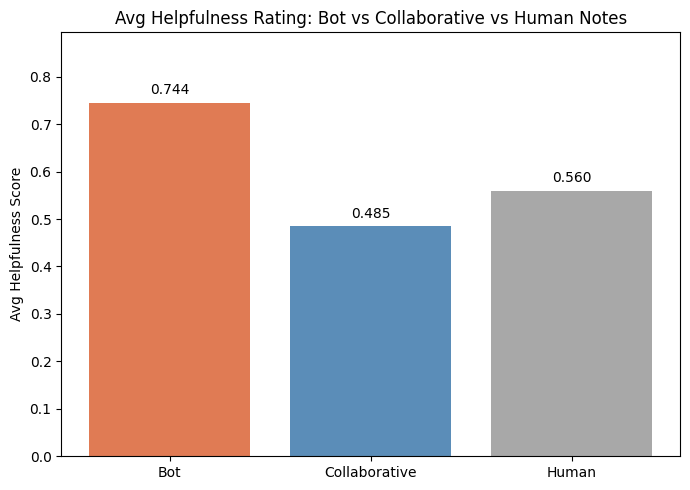

In [ ]:
# Assign each note to a category: Bot takes priority over Collaborative
def get_category(row):
    if row["isBot"] == 1:
        return "Bot"
    elif row["isCollaborativeNote"] == 1:
        return "Collaborative"
    else:
        return "Human"


ratings_with_category["category"] = ratings_with_category.apply(get_category, axis=1)

# Average helpfulness score per category (rating-level aggregation)
avg_helpfulness_by_category = ratings_with_category.groupby("category")["helpfulScore"].mean()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    avg_helpfulness_by_category.index,
    avg_helpfulness_by_category.values,
    color=["#e07b54", "#5b8db8", "#a8a8a8"],
)
ax.bar_label(bars, fmt="%.3f", padding=4)
ax.set_ylim(0, avg_helpfulness_by_category.max() * 1.2)
ax.set_ylabel("Avg Helpfulness Score")
ax.set_title("Avg Helpfulness Rating: Bot vs Collaborative vs Human Notes")
plt.tight_layout()
plt.show()

In [ ]:
# Note status history: contains currentStatus and timestampMillisOfFirstNonNMRStatus per note
note_status_history = pd.read_csv(f"{DATA_DIR}/noteStatusHistory-00000.tsv", sep="\t", low_memory=False)

In [ ]:
note_status_history.columns

Index(['noteId', 'noteAuthorParticipantId', 'createdAtMillis',
       'timestampMillisOfFirstNonNMRStatus', 'firstNonNMRStatus',
       'timestampMillisOfCurrentStatus', 'currentStatus',
       'timestampMillisOfLatestNonNMRStatus', 'mostRecentNonNMRStatus',
       'timestampMillisOfStatusLock', 'lockedStatus',
       'timestampMillisOfRetroLock', 'currentCoreStatus',
       'currentExpansionStatus', 'currentGroupStatus', 'currentDecidedBy',
       'currentModelingGroup', 'timestampMillisOfMostRecentStatusChange',
       'timestampMillisOfNmrDueToMinStableCrhTime', 'currentMultiGroupStatus',
       'currentModelingMultiGroup', 'timestampMinuteOfFinalScoringOutput',
       'timestampMillisOfFirstNmrDueToMinStableCrhTime'],
      dtype='object')

In [ ]:
note_status_history.head()

,noteId,noteAuthorParticipantId,createdAtMillis,timestampMillisOfFirstNonNMRStatus,firstNonNMRStatus,timestampMillisOfCurrentStatus,currentStatus,timestampMillisOfLatestNonNMRStatus,mostRecentNonNMRStatus,timestampMillisOfStatusLock,...,currentExpansionStatus,currentGroupStatus,currentDecidedBy,currentModelingGroup,timestampMillisOfMostRecentStatusChange,timestampMillisOfNmrDueToMinStableCrhTime,currentMultiGroupStatus,currentModelingMultiGroup,timestampMinuteOfFinalScoringOutput,timestampMillisOfFirstNmrDueToMinStableCrhTime
0,1352796878438424576,B021517F4F8F9F372DCD70BB8F8A21A80C12D7EFDE8B2F...,1611366884227,NaN,NaN,1721920068424,NEEDS_MORE_RATINGS,NaN,NaN,1.674003e+12,...,NEEDS_MORE_RATINGS,NEEDS_MORE_RATINGS,CoreModel (v1.1),13.0,-1,NaN,NaN,NaN,29540394,NaN
1,1353415873227177985,D4C9EDB464DF2D4A6D8F68CA8D1F86226B50EB9D3B0F33...,1611514464087,NaN,NaN,1721920068424,NEEDS_MORE_RATINGS,NaN,NaN,1.674003e+12,...,NEEDS_MORE_RATINGS,NEEDS_MORE_RATINGS,CoreModel (v1.1),13.0,-1,NaN,NaN,NaN,29540394,NaN
2,1354586938863443971,C0AF45F4C4B2240E7AB31456957E5D770FF7AFA13627C7...,1611793667892,NaN,NaN,1721920068424,NEEDS_MORE_RATINGS,NaN,NaN,1.674003e+12,...,NEEDS_MORE_RATINGS,NEEDS_MORE_RATINGS,CoreModel (v1.1),6.0,-1,NaN,NaN,NaN,29540394,NaN
3,1354588003075764229,9C480F7B2E882F19F9FBF75BD13FEA53031875AC42FDF6...,1611793921619,NaN,NaN,1721920068424,NEEDS_MORE_RATINGS,NaN,NaN,1.674003e+12,...,NaN,NaN,ExpansionPlusModel (v1.1),NaN,-1,NaN,NaN,NaN,29540394,NaN
4,1354588172659920899,931B6CFE7C2FDF3653B0A63DC20DF3C51F8AA3BEB9D613...,1611793962051,NaN,NaN,1721920068424,NEEDS_MORE_RATINGS,NaN,NaN,1.674003e+12,...,NaN,NaN,ExpansionPlusModel (v1.1),NaN,-1,NaN,NaN,NaN,29540394,NaN


In [ ]:
# Join status history into ratings DataFrame
# Result: rating-level DataFrame with status columns added (one row per rating)
ratings_with_status = ratings_with_category.merge(note_status_history, on="noteId", how="left")

In [ ]:
ratings_with_status.columns

Index(['noteId', 'raterParticipantId', 'createdAtMillis_x', 'version', 'agree',
       'disagree', 'helpful', 'notHelpful', 'helpfulnessLevel', 'helpfulOther',
       'helpfulInformative', 'helpfulClear', 'helpfulEmpathetic',
       'helpfulGoodSources', 'helpfulUniqueContext', 'helpfulAddressesClaim',
       'helpfulImportantContext', 'helpfulUnbiasedLanguage', 'notHelpfulOther',
       'notHelpfulIncorrect', 'notHelpfulSourcesMissingOrUnreliable',
       'notHelpfulOpinionSpeculationOrBias', 'notHelpfulMissingKeyPoints',
       'notHelpfulOutdated', 'notHelpfulHardToUnderstand',
       'notHelpfulArgumentativeOrBiased', 'notHelpfulOffTopic',
       'notHelpfulSpamHarassmentOrAbuse', 'notHelpfulIrrelevantSources',
       'notHelpfulOpinionSpeculation', 'notHelpfulNoteNotNeeded',
       'ratedOnTweetId', 'ratingSourceBucketed', 'suggestion', 'helpfulScore',
       'isBot', 'isCollaborativeNote', 'category', 'noteAuthorParticipantId',
       'createdAtMillis_y', 'timestampMillisOfFirstN

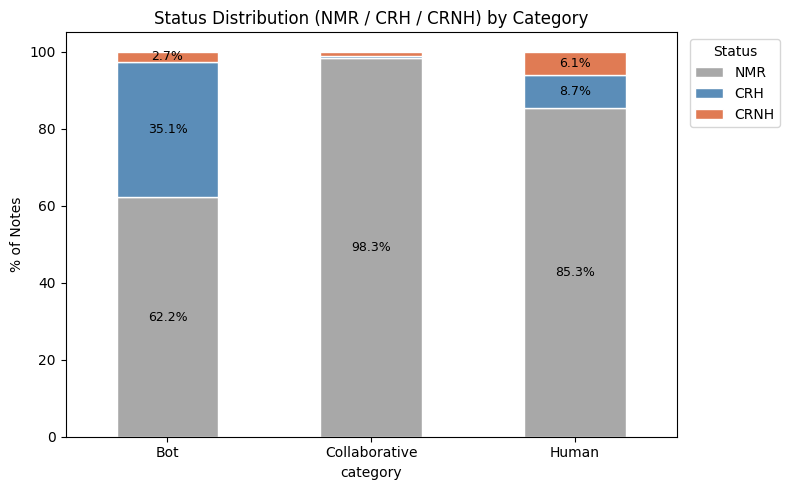

In [ ]:
# Deduplicate to note-level for status distribution (avoids inflating counts by rating volume)
note_level = ratings_with_status.drop_duplicates(subset="noteId")

status_counts_by_category = (
    note_level.groupby(["category", "currentStatus"]).size().unstack(fill_value=0)
)
status_pct_by_category = status_counts_by_category.div(status_counts_by_category.sum(axis=1), axis=0) * 100

# Rename full status strings to short labels
status_label_map = {
    "NEEDS_MORE_RATINGS": "NMR",
    "CURRENTLY_RATED_HELPFUL": "CRH",
    "CURRENTLY_RATED_NOT_HELPFUL": "CRNH",
}
status_pct_by_category = status_pct_by_category.rename(columns=status_label_map)

status_colors = {"NMR": "#a8a8a8", "CRH": "#5b8db8", "CRNH": "#e07b54"}
ax = status_pct_by_category[["NMR", "CRH", "CRNH"]].plot(
    kind="bar",
    stacked=True,
    color=[status_colors[c] for c in ["NMR", "CRH", "CRNH"]],
    figsize=(8, 5),
    edgecolor="white",
)

for bar_group in ax.containers:
    ax.bar_label(
        bar_group,
        fmt=lambda x: f"{x:.1f}%" if x > 2 else "",
        label_type="center",
        fontsize=9,
    )

plt.ylabel("% of Notes")
plt.title("Status Distribution (NMR / CRH / CRNH) by Category")
plt.xticks(rotation=0)
plt.legend(title="Status", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

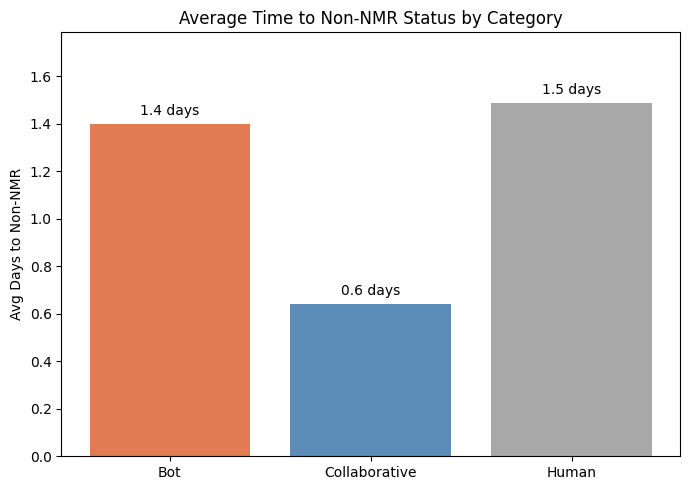

In [ ]:
# Compute time to non-NMR at note level (drop notes that never left NMR)
# Time is in milliseconds; convert to days
notes_with_nonNMR_time = note_level.dropna(subset=["timestampMillisOfFirstNonNMRStatus"]).copy()
notes_with_nonNMR_time["time_to_nonNMR_days"] = (
    notes_with_nonNMR_time["timestampMillisOfFirstNonNMRStatus"] - notes_with_nonNMR_time["createdAtMillis_y"]
) / (1000 * 60 * 60 * 24)

avg_days_to_nonNMR = notes_with_nonNMR_time.groupby("category")["time_to_nonNMR_days"].mean()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(avg_days_to_nonNMR.index, avg_days_to_nonNMR.values,
              color=["#e07b54", "#5b8db8", "#a8a8a8"])
ax.bar_label(bars, fmt="%.1f days", padding=4)
ax.set_ylim(0, avg_days_to_nonNMR.max() * 1.2)
ax.set_ylabel("Avg Days to Non-NMR")
ax.set_title("Average Time to Non-NMR Status by Category")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

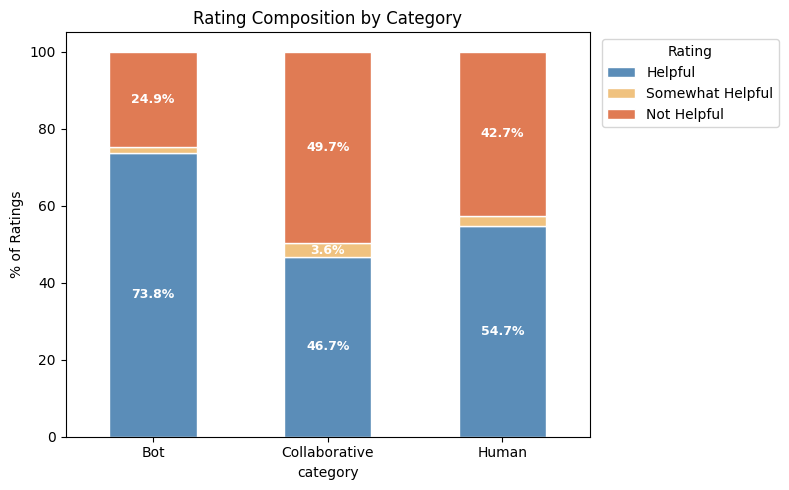

In [ ]:
# Rating composition: breakdown of HELPFUL / SOMEWHAT_HELPFUL / NOT_HELPFUL per category
# Uses rating-level data (one row per rating)
rating_composition_pct = (
    ratings_with_status.groupby("category")["helpfulnessLevel"]
    .value_counts(normalize=True)
    .unstack()
    * 100
)

helpfulness_label_map = {
    "HELPFUL": "Helpful",
    "SOMEWHAT_HELPFUL": "Somewhat Helpful",
    "NOT_HELPFUL": "Not Helpful",
}
rating_composition_pct = rating_composition_pct.rename(columns=helpfulness_label_map)

ax = rating_composition_pct[["Helpful", "Somewhat Helpful", "Not Helpful"]].plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=["#5b8db8", "#f0c27f", "#e07b54"],
    edgecolor="white",
)

for bar_group in ax.containers:
    ax.bar_label(
        bar_group,
        fmt=lambda x: f"{x:.1f}%" if x > 3 else "",
        label_type="center",
        fontsize=9,
        color="white",
        fontweight="bold",
    )

plt.title("Rating Composition by Category")
plt.ylabel("% of Ratings")
plt.xticks(rotation=0)
plt.legend(title="Rating", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()


First Colab note, last, best (y axis) highest helpfulness per tweet

/tmp/ipykernel_21575/3786488139.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


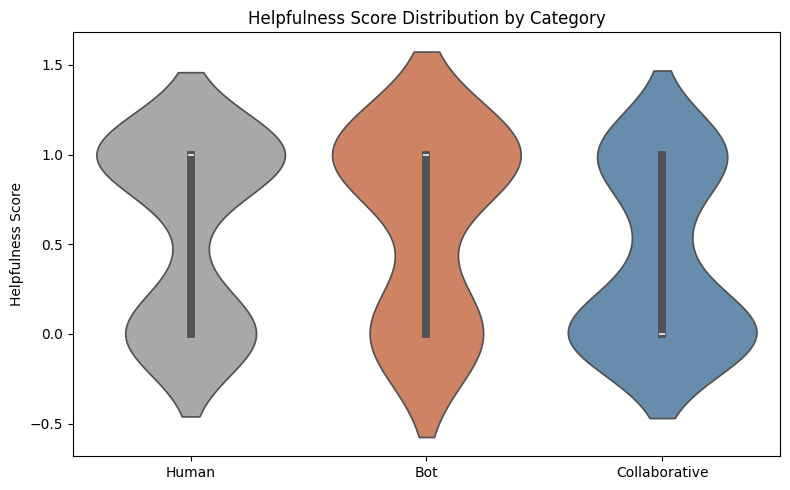

In [ ]:
import seaborn as sns

# Violin plot: shows full distribution of helpfulness scores
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(
    data=notes_with_nonNMR_time,
    x="category",
    y="helpfulScore",
    palette={"Bot": "#e07b54", "Collaborative": "#5b8db8", "Human": "#a8a8a8"},
    inner="box",
    ax=ax,
)
ax.set_title("Helpfulness Score Distribution by Category")
ax.set_ylabel("Helpfulness Score")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

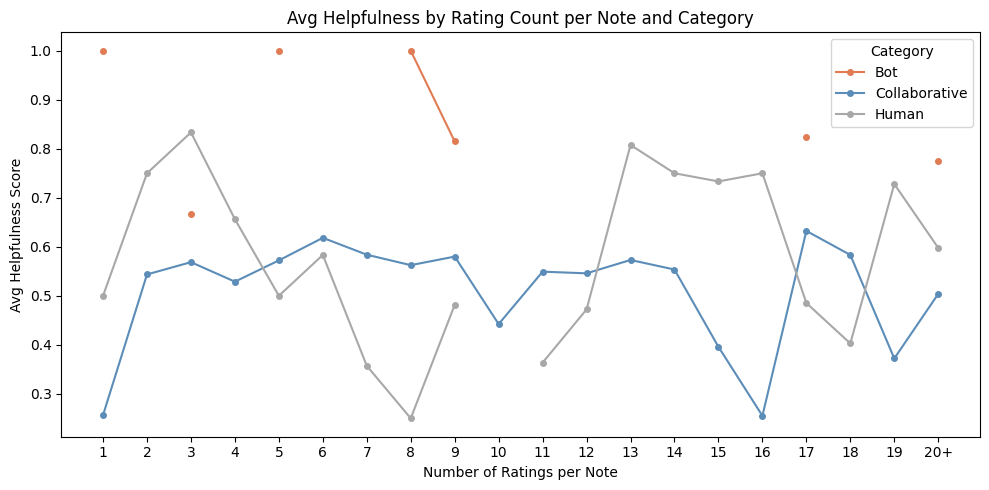

In [ ]:
# Aggregate to note level: avg helpfulness and total rating count per note
note_rating_stats = (
    ratings_with_status.groupby("noteId")["helpfulScore"]
    .agg(["mean", "count"])
    .reset_index()
)
note_rating_stats.columns = ["noteId", "avg_helpfulness", "rating_count"]
note_rating_stats = note_rating_stats.merge(
    notes[["noteId", "isBot", "isCollaborativeNote"]], on="noteId"
)
note_rating_stats["category"] = note_rating_stats.apply(get_category, axis=1)

# Cap at 20, group everything above as 20+
note_rating_stats["rating_bin"] = note_rating_stats["rating_count"].clip(upper=20)

helpfulness_by_volume_cat = (
    note_rating_stats.groupby(["rating_bin", "category"])["avg_helpfulness"]
    .mean()
    .unstack()
)

ax = helpfulness_by_volume_cat.plot(
    kind="line",
    marker="o",
    markersize=4,
    figsize=(10, 5),
    color={"Bot": "#e07b54", "Collaborative": "#5b8db8", "Human": "#a8a8a8"},
)

# Relabel x-axis: 1–19 as numbers, 20 as "20+"
xtick_labels = [
    str(int(x)) if x < 20 else "20+" for x in helpfulness_by_volume_cat.index
]
ax.set_xticks(helpfulness_by_volume_cat.index)
ax.set_xticklabels(xtick_labels, rotation=0)

plt.title("Avg Helpfulness by Rating Count per Note and Category")
plt.xlabel("Number of Ratings per Note")
plt.ylabel("Avg Helpfulness Score")
plt.legend(title="Category")
plt.tight_layout()
plt.show()


How many colaborative notes are helpful, how much tweet in batsignal

In [4]:
import pandas as pd

In [7]:
# Note status history: contains currentStatus and timestampMillisOfFirstNonNMRStatus per note
note_status_history = pd.read_csv(
    f"{DATA_DIR}/noteStatusHistory-00000.tsv", sep="\t", low_memory=False
)


In [8]:
note_status_history.columns

Index(['noteId', 'noteAuthorParticipantId', 'createdAtMillis',
       'timestampMillisOfFirstNonNMRStatus', 'firstNonNMRStatus',
       'timestampMillisOfCurrentStatus', 'currentStatus',
       'timestampMillisOfLatestNonNMRStatus', 'mostRecentNonNMRStatus',
       'timestampMillisOfStatusLock', 'lockedStatus',
       'timestampMillisOfRetroLock', 'currentCoreStatus',
       'currentExpansionStatus', 'currentGroupStatus', 'currentDecidedBy',
       'currentModelingGroup', 'timestampMillisOfMostRecentStatusChange',
       'timestampMillisOfNmrDueToMinStableCrhTime', 'currentMultiGroupStatus',
       'currentModelingMultiGroup', 'timestampMinuteOfFinalScoringOutput',
       'timestampMillisOfFirstNmrDueToMinStableCrhTime'],
      dtype='object')

In [10]:
notes = pd.read_csv(f"{DATA_DIR}/notes_all.csv")


In [11]:
note_with_history = notes.merge(note_status_history, on="noteId", how="left")

In [12]:
note_with_history.columns

Index(['noteId', 'noteAuthorParticipantId_x', 'createdAtMillis_x', 'tweetId',
       'classification', 'believable', 'harmful', 'validationDifficulty',
       'misleadingOther', 'misleadingFactualError',
       'misleadingManipulatedMedia', 'misleadingOutdatedInformation',
       'misleadingMissingImportantContext', 'misleadingUnverifiedClaimAsFact',
       'misleadingSatire', 'notMisleadingOther',
       'notMisleadingFactuallyCorrect',
       'notMisleadingOutdatedButNotWhenWritten', 'notMisleadingClearlySatire',
       'notMisleadingPersonalOpinion', 'trustworthySources', 'summary',
       'isMediaNote', 'isCollaborativeNote', 'isBot',
       'noteAuthorParticipantId_y', 'createdAtMillis_y',
       'timestampMillisOfFirstNonNMRStatus', 'firstNonNMRStatus',
       'timestampMillisOfCurrentStatus', 'currentStatus',
       'timestampMillisOfLatestNonNMRStatus', 'mostRecentNonNMRStatus',
       'timestampMillisOfStatusLock', 'lockedStatus',
       'timestampMillisOfRetroLock', 'currentC

In [13]:
colab_helpful = note_with_history[(note_with_history["currentStatus"] == "CURRENTLY_RATED_HELPFUL") & (note_with_history["isCollaborativeNote"] == 1)].copy()

In [14]:
colab_helpful.shape

(73, 47)

In [24]:
print("# of unique tweet IDs that CRH and is_collaborative:", colab_helpful["tweetId"].nunique())

# of unique tweet IDs that CRH and is_collaborative: 72


In [16]:
signal = pd.read_csv(f"{DATA_DIR}/batSignals-00000.tsv", sep="\t", low_memory=False)

In [ ]:
colab_helpful_tweet_ids = set(colab_helpful["tweetId"])
colab_helpful_tweet = signal[signal["tweetId"].isin(colab_helpful_tweet_ids)].copy()

In [26]:
print("Number of CRH + Colab tweets in the signal data:", colab_helpful_tweet["tweetId"].nunique())

Number of CRH + Colab tweets in the signal data: 70


In [ ]:
colab_helpful

In [ ]:
# Aggregate to note level: avg helpfulness and total rating count per note
note_rating_stats = (
    ratings_with_status.groupby("noteId")["helpfulScore"]
    .agg(["mean", "count"])
    .reset_index()
)
note_rating_stats.columns = ["noteId", "avg_helpfulness", "rating_count"]
note_rating_stats = note_rating_stats.merge(
    notes[["noteId", "isBot", "isCollaborativeNote"]], on="noteId"
)
note_rating_stats["category"] = note_rating_stats.apply(get_category, axis=1)

# Cap at 20, group everything above as 20+
note_rating_stats["rating_bin"] = note_rating_stats["rating_count"].clip(upper=20)

helpfulness_by_volume_cat = (
    note_rating_stats.groupby(["rating_bin", "category"])["avg_helpfulness"]
    .mean()
    .unstack()
)

ax = helpfulness_by_volume_cat.plot(
    kind="line",
    marker="o",
    markersize=4,
    figsize=(10, 5),
    color={"Bot": "#e07b54", "Collaborative": "#5b8db8", "Human": "#a8a8a8"},
)

# Relabel x-axis: 1–19 as numbers, 20 as "20+"
xtick_labels = [
    str(int(x)) if x < 20 else "20+" for x in helpfulness_by_volume_cat.index
]
ax.set_xticks(helpfulness_by_volume_cat.index)
ax.set_xticklabels(xtick_labels, rotation=0)

plt.title("Avg Helpfulness by Rating Count per Note and Category")
plt.xlabel("Number of Ratings per Note")
plt.ylabel("Avg Helpfulness Score")
plt.legend(title="Category")
plt.tight_layout()
plt.show()


Average Rating vs 